In [1]:
import numpy as np
from statsmodels.tsa.arima_process import ArmaProcess
import pandas as pd

from statsmodels.tsa.api import ARIMA
from statsmodels.stats.api import het_arch, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_predict

import pandas_datareader.data as web

# настройки визуализации
import matplotlib.pyplot as plt

# Не показывать Warnings
import warnings
warnings.simplefilter(action='ignore', category=Warning)
# Не показывать ValueWarning, ConvergenceWarning из statsmodels
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning
warnings.simplefilter('ignore', category=ValueWarning)
warnings.simplefilter('ignore', category=ConvergenceWarning)

In [2]:
y = web.DataReader(name='DGS10', data_source='fred', start='2010-01')
y

,DGS10
DATE,
2010-01-01,NaN
2010-01-04,3.85
2010-01-05,3.77
2010-01-06,3.85
2010-01-07,3.85
...,...
2026-03-09,4.12
2026-03-10,4.15
2026-03-11,4.21


In [3]:
# спецификация модели
mod = ARIMA(y, order=(3,0,2), trend='n', missing='drop')
# подгонка модели на данных
res = mod.fit()
# выводим результаты подгонки
res.summary(alpha=0.05)

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  DGS10   No. Observations:                 4226
Model:                 ARIMA(3, 0, 2)   Log Likelihood                6111.727
Date:                Tue, 17 Mar 2026   AIC                         -12211.453
Time:                        20:55:07   BIC                         -12173.359
Sample:                    01-01-2010   HQIC                        -12197.988
                         - 03-13-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1292      0.336      3.358      0.001       0.470       1.788
ar.L2         -0.2422      0.541     -0.448      0.654      -1.302       0.818
ar.L3          0.1129      0.288      0.392      0.695      -0.451       0.677
ma.L1         -0.1455      0.337     -0.431      0.666      -0.807       0.516
ma.L2          0.0713      0.291      0.245      0.806      -0.499       0.642
sigma2         0.0028   4.59e-05     60.451      0.000       0.003       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):               611.25
Prob(Q):                              0.78   Prob(JB):                         0.00
Heteroskedasticity (H):               1.24   Skew:                            -0.02
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [4]:
forecasts = res.forecast(steps=10)
forecasts

2026-03-16    4.276446
2026-03-17    4.275429
2026-03-18    4.275250
2026-03-19    4.274892
2026-03-20    4.274417
2026-03-23    4.273946
2026-03-24    4.273490
2026-03-25    4.273035
2026-03-26    4.272578
2026-03-27    4.272122
Freq: B, Name: predicted_mean, dtype: float64

In [5]:
# спецификация модели
mod2 = ARIMA(y, order=(3,0,2), trend='c')
# подгонка модели на данных
res2 = mod2.fit()
forecasts2 = res2.forecast(steps=10)
forecasts2

2026-03-16    4.275092
2026-03-17    4.272738
2026-03-18    4.271246
2026-03-19    4.269538
2026-03-20    4.267698
2026-03-23    4.265871
2026-03-24    4.264064
2026-03-25    4.262260
2026-03-26    4.260456
2026-03-27    4.258654
Freq: B, Name: predicted_mean, dtype: float64

In [6]:
# спецификация модели
mod3 = ARIMA(y, order=(3,1,0), trend='t')
# подгонка модели на данных
res3 = mod3.fit()
forecasts3 = res3.forecast(steps=10)
forecasts3

2026-03-16    4.276720
2026-03-17    4.275806
2026-03-18    4.275958
2026-03-19    4.276132
2026-03-20    4.276236
2026-03-23    4.276327
2026-03-24    4.276422
2026-03-25    4.276518
2026-03-26    4.276615
2026-03-27    4.276711
Freq: B, Name: predicted_mean, dtype: float64

In [7]:
# спецификация модели
mod4 = ARIMA(y, order=(3,1,1), trend='n')
# подгонка модели на данных
res4 = mod4.fit()
forecasts4 = res4.forecast(steps=10)
forecasts4

2026-03-16    4.276612
2026-03-17    4.275588
2026-03-18    4.275637
2026-03-19    4.275716
2026-03-20    4.275724
2026-03-23    4.275720
2026-03-24    4.275719
2026-03-25    4.275719
2026-03-26    4.275719
2026-03-27    4.275719
Freq: B, Name: predicted_mean, dtype: float64

In [8]:
# спецификация модели
mod5 = ARIMA(y, order=(2,2,0), trend='n')
# подгонка модели на данных
res5 = mod5.fit()
forecasts5 = res5.forecast(steps=10)
forecasts5

2026-03-16    4.323169
2026-03-17    4.362397
2026-03-18    4.392257
2026-03-19    4.429756
2026-03-20    4.465571
2026-03-23    4.499744
2026-03-24    4.535614
2026-03-25    4.570952
2026-03-26    4.606029
2026-03-27    4.641472
Freq: B, Name: predicted_mean, dtype: float64

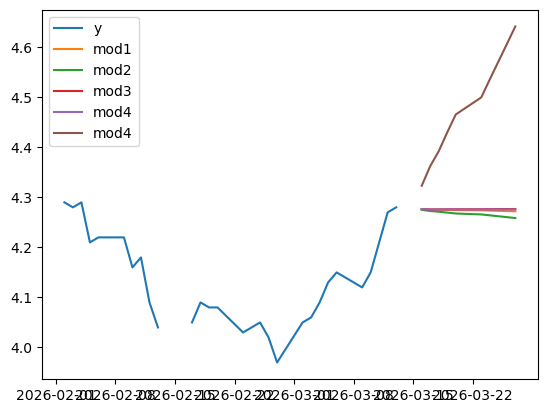

In [9]:
plt.plot(y.tail(30), label='y')
plt.plot(forecasts, label='mod1')
plt.plot(forecasts2, label='mod2')
plt.plot(forecasts3, label='mod3')
plt.plot(forecasts4, label='mod4')
plt.plot(forecasts5, label='mod4')

plt.legend()

plt.show()

In [10]:
# Модель для прогнозирования, например ARIMA
from sktime.forecasting.arima import ARIMA
# Визуализация временных рядов
from sktime.utils.plotting import plot_series
# Модули для кросс-валидации
from sktime.split import temporal_train_test_split, ExpandingWindowSplitter, SlidingWindowSplitter, SingleWindowSplitter
from sktime.forecasting.model_evaluation import evaluate
from sktime.performance_metrics.forecasting import MeanSquaredError, MeanAbsoluteError, MeanAbsolutePercentageError # Метрики MSE, MAE, MAPE
# Поиск оптимальных гиперпараметров по сетке
from sktime.forecasting.model_selection import ForecastingGridSearchCV

# Не показывать Warnings
import warnings
warnings.simplefilter(action='ignore', category=Warning)
warnings.filterwarnings("ignore", category=FutureWarning)
# Не показывать ValueWarning, ConvergenceWarning из statsmodels
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning
warnings.simplefilter('ignore', category=ValueWarning)
warnings.simplefilter('ignore', category=ConvergenceWarning)

In [1]:
# Зададим список из специфицированных моделей прогнозирования
forecasters = [ARIMA(order=(3,0,2), trend='n'), ARIMA(order=(3,0,2), trend='c'), ARIMA(order=(3,1,0), trend='t'), 
               ARIMA(order=(3,1,1), trend='n'), ARIMA(order=(2,2,0), trend='n')]

# специфицируем метод кросс-валидации. Например, SlidingWindowSplitter
cv_strategy = SlidingWindowSplitter(fh=np.arange(1, 6), initial_window=100, step_length=5)

# инициализируем метрики
metric = [MeanSquaredError(square_root=False), MeanAbsoluteError(), MeanAbsolutePercentageError()]

# датафрейм с метриками по столбцам
cv_data = pd.DataFrame(data=None, columns=['MSE', 'MAE', 'MAPE'])

for model in forecasters:
	print(model)
	cv_res = evaluate(forecaster=model, y=y, cv=cv_strategy, strategy="refit", return_data=False, scoring=metric)
	# print(df.iloc[:,:len(metric)].mean()) # метрики для каждой модели
	cv_data.loc[len(cv_data.index)] = cv_res.iloc[:,[0,1,2]].mean().values

# результаты кросс-валидации в виде датафрейма
cv_data

NameError: name 'ARIMA' is not defined